# Lesson 102 — Temporal Graph Networks: memory without time travel

Student edition. Three live functions control the model trained below.

In [ ]:
# @colab-bootstrap — standalone; no course package is required.
import sys
print('Python',sys.version.split()[0])

## Runtime and data

CPU author runs use Python 3.12, PyTorch 2.13.0+cpu, NumPy 2.5.0, pandas 3.0.3 and scikit-learn 1.9.0. See the downloadable requirements file. A missing package can be installed with `%pip install torch numpy pandas scikit-learn`; that creates a different, explicitly recorded runtime. First execution downloads a 534 MiB hash-checked data file and writes a processed cache. Allow about 2 GiB RAM for the notebook. Live Colab and fresh installation are NOT_CHECKED.

The default is a real-data teaching run. The complete named experiment uses the same visible model and trainer, gated after EXIT.

<div class="package-links"><strong>Your deliverable:</strong> implement the message → memory path, explain its timing, and defend a complete Wikipedia TGN-attn replay.<br><a href="https://avistian.github.io/relational/labs/0102-temporal-graph-networks.ipynb">Student notebook</a> · <a href="https://avistian.github.io/relational/labs/solutions/0102-temporal-graph-networks.ipynb">Executed solution</a> · <a href="https://avistian.github.io/relational/labs/html/0102-temporal-graph-networks.html">Read the lab</a> · <a href="https://avistian.github.io/relational/labs/l102-reproduction.md">Reproduction contract</a></div>

## 1 · Retrieve before reading

**Retrieval first:** write your answers before opening the feedback.

Close the notes. What makes a neighbor legal at a historical prediction time in [L101](https://avistian.github.io/relational/lessons/0101-static-vs-temporal.html)? Why does [L097](https://avistian.github.io/relational/lessons/0097-negative-sampling.html) distinguish sampled negatives from full-catalog ranking? In [L098](https://avistian.github.io/relational/lessons/0098-hetero-mini-batching.html), what is shared across a mini-batch and what depends on each seed query?

<details><summary>Feedback — open after making an attempt</summary><p>Inputs must have been observable by the query cutoff, including their feature versions. Candidate sampling changes the evaluation question. Model weights are shared, while the seed identities and sampled dependencies specify each computation. Today, a fourth object matters: a mutable per-node state that must correspond to the correct historical point.</p></details>

**The tangible win.** Given an event stream, you can say exactly which event first affects a node’s memory, which prediction can read it, and which loss trains the memory updater. Work through sections 2–6 first. Then implement the three notebook tasks. Treat the full benchmark as a separate, longer experiment.

**Why this belongs in the mission.** A relational database records interactions: purchases, messages, edits, appointments. L101 established which records are legal. It did not show how a model can compress a long stream into a useful state. TGN supplies that mechanism. Whether it improves a real relational task remains an empirical question with a declared evaluation protocol.

Primary reading: [Rossi et al., 2020, §§3.1–3.2, Figure 2 and Appendix A.2](https://arxiv.org/html/2006.10637v3). Read those sections alongside the computation below. The implementation reference is the [publication-era release](https://github.com/twitter-research/tgn/tree/e38cdf85998c6ca077167610dc4e769a688efa95).

## 2 · An event changes history; a query asks about history

**An event** is an observed interaction `(u, v, t, e)`: source node, destination node, timestamp and event feature vector. Wikipedia gives user–page edits. User 7 and page 7 need distinct node IDs, just as the two sides of the bipartite graph did in [L095](https://avistian.github.io/relational/lessons/0095-bipartite-graphs.html). Repeated edits are separate events, not duplicate edges to discard. Each prediction query supplies its timestamp; the decoder scores a candidate interaction at that time.

**Memory** `sᵢ` is a vector summarizing previously consumed events for node `i`. **Last-update time** `τᵢ` says when its most recently incorporated event occurred. A new node starts with zero memory. Neither object is a learned ID embedding: the updater’s shared weights are learned, while each node’s memory is computed from its history.

**An embedding** `zᵢ(t)` is the representation used for a particular query. Memory and embedding are different. A node may not interact for an hour, so its stored memory stays unchanged. Its neighbors can still change. A query-time graph operator lets its embedding consult those neighbors and the elapsed times.

> **In plain terms.** Memory is the running notebook; the embedding is the answer you construct from that notebook and the legal neighborhood when someone asks a question.

**Worked example.** A edits B at time 1; A edits C at time 2; B interacts with C at time 3. Before the first event, all memories are zero. After observing the first event, A and B have information that C lacks. But if the first two events are predicted together, their memory inputs must share a declared batch boundary. Do not quietly turn batch inference into sequential event inference.

## 3 · Model architecture: trace the two paths

<figure class="tgn-figure" tabindex="0">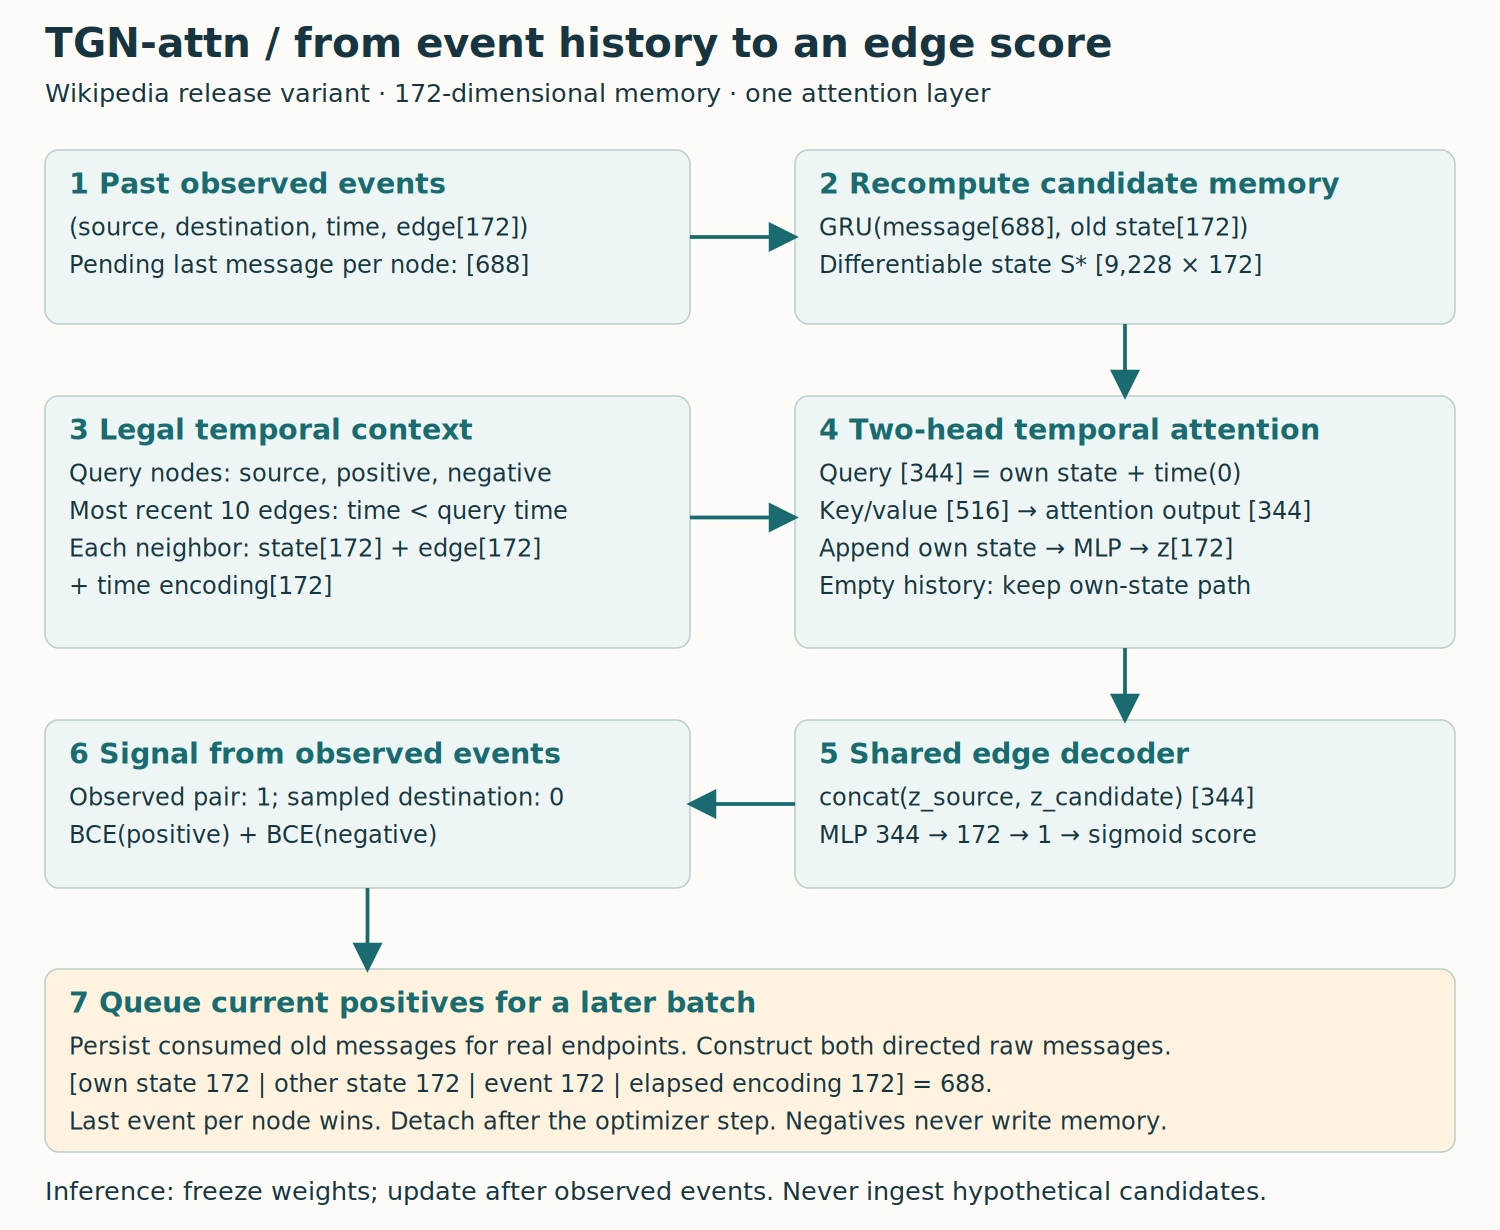<figcaption>Trace the prediction path and the delayed state path. This is the complete released one-layer TGN-attn shape contract.</figcaption></figure>

**Prediction path.** A batch of `B` real interactions creates `3B` node queries: sources, true destinations and sampled destinations. For each query, retrieve up to ten prior interactions. The same encoder weights process every node. The same decoder scores positive and negative pairs.

**State path.** Pending messages from older batches produce a differentiable candidate memory. The candidate serves the current prediction. Only after that prediction do the current real events create new pending messages. Random negative pairs do not update the event history.

The pictured variant is **TGN-attn** from Table 1: last-message aggregation, identity message function, a GRU updater and one two-head graph-attention layer. All three feature widths are 172 in the Wikipedia release. “Identity message” means concatenate the inputs without an additional learned MLP; it does not mean copy the old state unchanged.

**The dimensions are a useful checksum.** A message contains two 172-wide states, a 172-wide event vector and a 172-wide time encoding: `688` numbers. A query contains state and zero-lag time encoding: `344`. Each key/value input contains neighbor state, historical edge features and relative-time encoding: `516`. Attention returns `344` numbers; a merge MLP brings this back to a 172-wide embedding. See the released [temporal attention layer](https://github.com/twitter-research/tgn/blob/e38cdf85998c6ca077167610dc4e769a688efa95/model/temporal_attention.py).

## 4 · Build one message, aggregate repeated nodes, update memory

### 4.1 What information enters a message?

The message for A after event `(A,B,t,e)` uses A’s state, B’s state, the observed event features and the elapsed time since A’s previous update. The reverse message swaps the endpoint roles and uses B’s own elapsed time. Different last-update times mean the two time encodings need not agree.

<div class="tgn-equation">m_A = concat(s_A, s_B, e, φ(t − τ_A))<br>m_B = concat(s_B, s_A, e, φ(t − τ_B))</div>

The time encoder is a learned cosine bank: coordinate `k` is `cos(wₖ Δt + bₖ)`. `Δt` is the elapsed duration; `wₖ` controls how quickly that coordinate oscillates; `bₖ` is its phase. It converts one duration into multiple smooth numerical features. These weights receive gradients where the encoding participates in the prediction graph. The [released initializer](https://github.com/twitter-research/tgn/blob/e38cdf85998c6ca077167610dc4e769a688efa95/model/time_encoding.py) spreads frequencies from 1 to 10⁻⁹ and initializes phases to zero. L103 will examine time encoding in more detail.

### 4.2 Which message survives a batch?

**Worked example.** The ordered recipient IDs are `[B,A,B,A]`. Their message positions are `[0,1,2,3]`. Last-message aggregation returns position 3 for A and position 2 for B: `[3,2]` in sorted-node order. Selecting the first occurrence or averaging the messages changes the model.

This rule assumes chronological input. For timestamp ties, the release keeps the last record in stream order. It is not a permutation-invariant set reduction. Our real-data replay retains the input order and exact split IDs.

**Task 1** implements this index selection. **Task 2** constructs the two directed messages. Both functions are called by the model you train; they are not disconnected worksheet exercises.

### 4.3 Why a GRU instead of replacing the state?

A **gated recurrent unit (GRU)** learns how much old information to retain. Let `m` be the aggregated message and `s` the old memory. Every gate below is a vector with the same width as `s`. `σ` is the sigmoid function, mapping a real number into `(0,1)`; `⊙` means coordinate-wise multiplication.

<div class="tgn-equation">r = σ(Wᵣm + bᵣ + Uᵣs + cᵣ)<br>z = σ(W_zm + b_z + U_zs + c_z)<br>n = tanh(W_nm + b_n + r ⊙ (U_ns + c_n))<br>s_new = (1 − z) ⊙ n + z ⊙ s</div>

`W` matrices transform the message; `U` matrices transform the old state; `b` and `c` are learned biases. The reset gate `r` controls the old-state contribution inside the candidate `n`. The update gate `z` controls retention in the final mixture. This is the [PyTorch GRUCell convention](https://docs.pytorch.org/docs/stable/generated/torch.nn.GRUCell.html): a larger `z` retains more old memory. Other texts sometimes name the complementary gate `z`.

<figure class="tgn-figure" tabindex="0">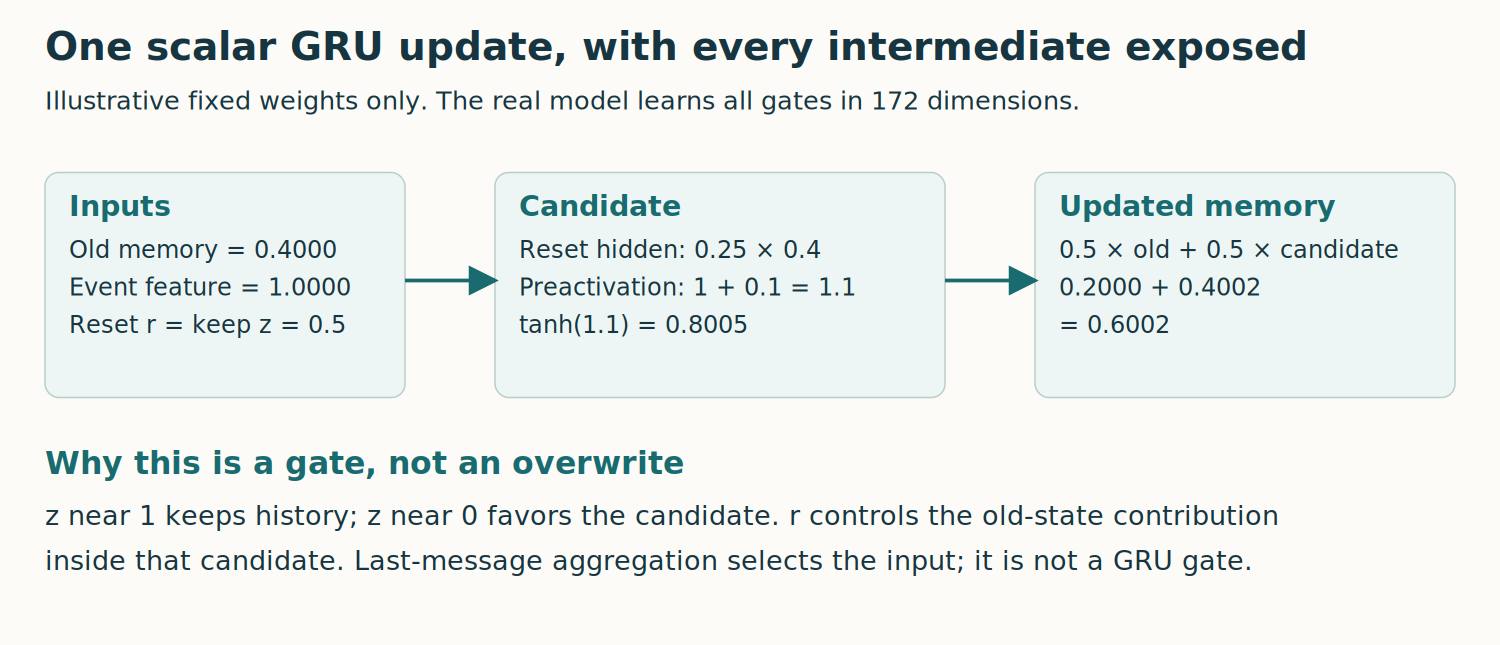<figcaption>A computed scalar GRU illustration: old state 0.4, candidate 0.8005, new state 0.6002 after rounding.</figcaption></figure>

**Worked example.** Hold both gates at `0.5`, old memory at `0.4`, input contribution at `1`, hidden candidate weight at `0.5`, and hidden bias at zero. The reset-weighted hidden contribution is `0.5 × 0.5 × 0.4 = 0.1`. The candidate is `tanh(1.1) = 0.8005`. Updated memory is `0.5 × 0.4 + 0.5 × 0.8005 = 0.6002` after rounding. This is a one-coordinate illustration, not a measured Wikipedia state.

**Task 3** applies the GRU only to selected nodes, records their update times and returns a candidate state without mutating its input. Its CHECK checks both values and gradients. Unchanged nodes must retain their old values.

## 5 · The training puzzle: learn from history without predicting yourself

**Commit a prediction:** which messages may update memory before the next batch is scored? Explain the gradient path.

A naive loop predicts an event, updates memory, then detaches the state. Its loss was computed before that update, so the updater has no path into that loss. Moving the current event’s update before the prediction gives a gradient but leaks the answer. The [paper’s Figure 2](https://arxiv.org/html/2006.10637v3#S3.F2) resolves both problems with delayed messages.

<figure class="tgn-figure" tabindex="0">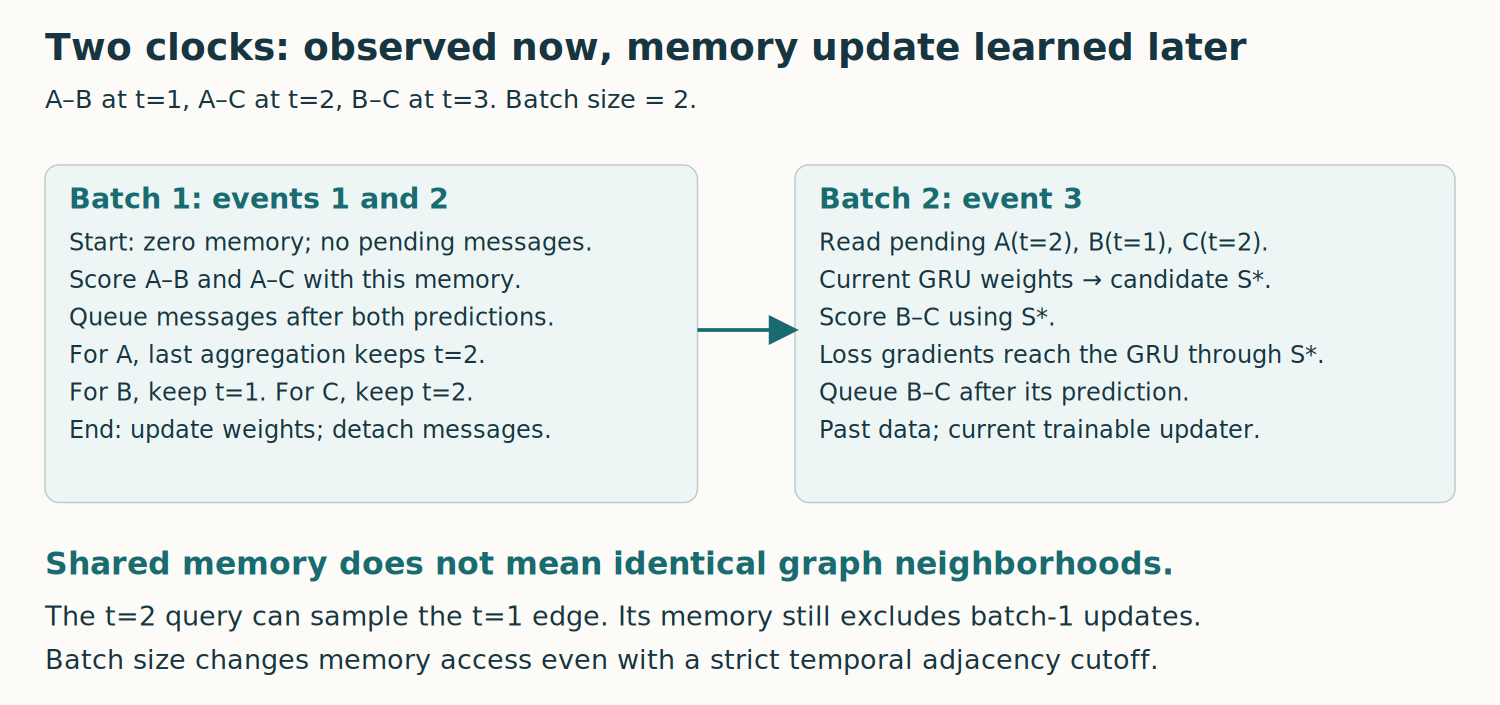<figcaption>Two events share batch-1 memory; batch 2 applies their stored messages through the trainable updater.</figcaption></figure>

**Step 1 — read pending history.** Take messages from events that were observed in earlier batches. They are ordinary stored data at this point.

**Step 2 — recompute the update.** Apply the current GRU weights to those messages and the stored memory. This produces candidate state `S*` inside the current autograd graph. Autograd records the operations needed to differentiate the loss.

**Step 3 — predict and train.** Build embeddings from `S*`, score the real and sampled pairs, compute the loss, and update the model weights. The chain `loss → embedding → S* → GRU weights` is intact.

**Step 4 — preserve the temporal boundary.** Consume old messages for current real endpoints and queue messages describing the newly observed real events. Detach memory and pending messages between optimizer steps. Detaching preserves values while cutting the gradient graph, preventing backpropagation through the entire event history.

**Read the actual training call.** The notebook exposes this loop and the `probabilities` method it calls. `p` and `n` are the positive and negative scores; the loss below is the sum of their two mean binary cross-entropies.

```python
optimizer.zero_grad()
p, n = model.probabilities(u, v, sampled_destinations, times, edge_ids)
loss = nn.functional.binary_cross_entropy(p, torch.ones_like(p))
loss = loss + nn.functional.binary_cross_entropy(n, torch.zeros_like(n))
loss.backward()
optimizer.step()
model.detach_state()
```

`probabilities` first builds the candidate state and embeddings, then commits consumed messages and queues new ones. The returned score tensors retain the candidate’s gradient path. Detaching earlier, before `backward`, would require care not to sever a needed graph; skipping the detach retains history across optimizer steps.

The released implementation computes scores from embeddings already made before it queues the current messages. The ordering inside a Python function is less important than the actual data dependency. A test that changes the current event’s features must leave its current score unchanged, while changing what future queries can read.

**A release detail about gradients.** The stored message vector already contains a time encoding. The release detaches that vector between batches, so a later loss does not backpropagate through its old encoding calculation. The shared time encoder still learns through query-time attention. The recomputed GRU update is the differentiable path we test here.

**Do not confuse memory with adjacency.** All queries in a batch share the same candidate memory. Their temporal neighbor cutoffs still differ. The query at time 2 can retrieve the time-1 edge even when both events belong to the same batch. The memory channel is stale within the batch; the neighborhood channel is filtered per query. This distinction explains why batch size is part of the scientific protocol, not just a performance setting.

## 6 · Intervene on the event stream

**Predict first.** For the second event, will changing batch size from two to one change A’s memory? Will allowing the current event to write memory change the current score even when the model weights stay fixed?

| Event 2 | Batch size 2 | Batch size 1 |
|---|---:|---:|
| Candidate A memory | 0 | 0.3808 |
| Candidate C memory | 0 | 0 |
| Illustrative score | 0.5000 | 0.5941 |

Use the linked HTML lesson for the interactive intervention.

This widget uses the scalar GRU from section 4 with zero initial state and a fixed illustrative decoder `sigmoid(s_source + s_destination)`. It displays prediction-time **candidate memory**, after applying previous-batch messages. The release physically commits only active endpoints; the widget’s fixed weights let us show the equivalent candidate values directly. It isolates the memory channel; there is no graph-attention contribution. Keep the event and weights fixed while switching batch size or the illegal update. The legal score remains visible beside the intervention.

<details><summary>Feedback</summary><p>At event 2 with batch size 2, A still has zero memory, so the legal scalar score is 0.5. With batch size 1, event 1 has updated A to 0.5 × tanh(1) ≈ 0.3808; C remains zero. The score becomes about 0.5941. Including event 2 before scoring changes inputs using the very event being predicted. That is leakage, not a better historical summary.</p></details>

## 7 · From memory to an actual prediction

**Temporal neighbors.** Find the ten most recent interactions strictly before each query timestamp. Node ID zero is padding. The original arrays are searched with a left insertion boundary, so same-time interactions are excluded from adjacency. Timestamp ties that cross memory batches need a separate ordering convention; a strict adjacency filter alone cannot guarantee that every state contribution has strictly earlier time.

**Attention.** Project the query and historical key/value inputs into two heads. Each head computes query–key dot products, scales them by the square root of its width, masks padding, and softmax-normalizes across neighbors. The weighted value sum selects relevant historical context. Concatenate the attention output with the node’s own state and pass it through a two-layer MLP. An MLP is a sequence of learned linear maps with a nonlinear activation between them.

An empty neighborhood needs explicit handling. Softmax over only masked positions is undefined. Temporarily allow one padding slot, compute attention, then zero the attention output for that query. Retain the own-state merge path. “No neighbors” is not the same as “no embedding.”

**Decoder and objective.** Concatenate a source embedding with a candidate destination embedding. A `344 → 172 → 1` MLP returns a logit; sigmoid turns it into a score between zero and one. For each observed interaction, sample one destination as a negative. Training minimizes the mean positive binary cross-entropy plus the mean negative binary cross-entropy:

<div class="tgn-equation">L = mean[−log p(real pair)] + mean[−log(1 − p(sampled pair))]</div>

The CSV also contains a node-classification label. This link-prediction replay ignores that column: its binary targets come from observed pairs and sampled pairs.

A sampled destination can coincide with a real or previously observed pair: the release does not reject those collisions. This is a property of its candidate protocol, not a guarantee that every sampled pair is an impossible interaction. L097’s candidate-set warning applies directly.

**Inference.** Freeze learned weights, not historical state. After a real interaction is observed, later queries may use it. Score all hypothetical candidate destinations against the same pre-observation state. Do not call a mutating event-consumption API repeatedly to rank hypothetical pairs; that would invent history. Back up and restore state for independent evaluation branches.

## 8 · Reproduce a named result, not a resemblance

The target is **Rossi et al. v3, Table 2, TGN-attn on Wikipedia**: AP `98.46 ± 0.1%` in the transductive column and `97.81 ± 0.1%` in the inductive column. The requested complete run covers all ten initializations, the full data and both evaluation branches. [Paper Table 2](https://arxiv.org/html/2006.10637v3#S5.T2).

**Held fixed.** One attention layer, two heads, ten recent neighbors, width 172, dropout 0.1, Adam at 0.0001, chronological batches of 200, up to 50 epochs and patience five. Select by all-event validation AP, never test AP. A fixed tolerance of 0.5 percentage point for each mean was recorded before results; it is a course closeness criterion, not a statistical equivalence test.

**Complete input.** The hash-pinned JODIE Wikipedia file has 157,474 events and 9,227 nodes. Zero padding adds one state row. The release’s 70% and 85% time quantiles define the cutoffs. It samples 10% of all nodes from nodes appearing after the first cutoff and removes their early interactions from training. The resulting partitions here have 81,029 training, 23,621 validation and 23,621 test events. New-node subsets contain 12,016 validation and 11,715 test events. New nodes mean nodes absent from the training interactions, including naturally late arrivals.

**What the metrics actually average.** AP, or average precision, summarizes precision as positive examples are recovered down a score ranking. Here the evaluator computes it separately for each chronological batch containing real and sampled pairs, then averages batch APs equally. It is not pooled AP over all events, and it is not full-catalog retrieval. Even the smaller final batch has equal weight. **Worked example:** sort scores 0.9, 0.8, 0.7, 0.1 with labels 1, 0, 1, 0. The positive ranks are 1 and 3, with precisions 1 and 2/3. AP is their mean, 5/6 ≈ 0.8333. For tied scores, evaluate precision after the whole tied group. The saved predictions permit an independent reconstruction of every batch metric.

**Names versus populations.** The release evaluates its “transductive” result on all test edges, including edges involving new nodes. The new-node branch evaluates only events involving at least one node absent from training. Its negative sampler draws from destination IDs appearing in that subset; that does not guarantee every sampled destination is itself unseen. We report the actual populations rather than silently rewriting the release to fit a label. The all-event sampler uses the full dataset’s destination-ID catalog, including future arrivals. That is a benchmark convention, not an unknown-catalog deployment simulation. The full evaluation neighbor index also restores pre-cutoff interactions of nodes withheld from training; they can serve as historical context at inference. Event timestamps are treated as observation times; delayed ingestion and historical feature versions from L101 need additional handling in a real database.

**Two different kinds of reproducibility.** The modern port uses explicit independent seeds 0–9. The original script seeds once before ten consecutive runs, so its later random streams depend on earlier runs and stopping times. Python 3.12 also requires converting a set to a tuple before `random.sample`; the archived split IDs make that choice auditable. We reproduce the released computation and documented modern protocol, while historical execution identity remains **INCOMPARABLE**.

**The checkpoint trap.** The release’s `state_dict` includes persistent memory and last-update times but excludes pending messages. Early stopping therefore restores the best weights and persistent memory while retaining stopping-epoch pending messages. The named replay preserves that choice and records it. A checked warm-state example changes its next probability by about 0.00164 when pending messages alone are omitted. A robust deployment checkpoint should save parameters, memory, clocks, pending messages, stream position and relevant RNG/optimizer state together. Fixing the historical behavior would define a separate experiment.

| Evaluation population | Measured mean AP | Seed sample SD | Paper AP | Numerical verdict |
|---|---:|---:|---:|---|
| All test events | 98.5123% | 0.0679 pp | 98.46% | CLOSE |
| New-node event subset | 97.8295% | 0.0861 pp | 97.81% | CLOSE |

**Execution: COMPLETE — seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].** Sample SD describes variation across initializations on this fixed dataset/split, not uncertainty across datasets. Historical identity: **INCOMPARABLE**. Full paper: **NOT_ESTABLISHED**.

<figure class="tgn-figure" tabindex="0">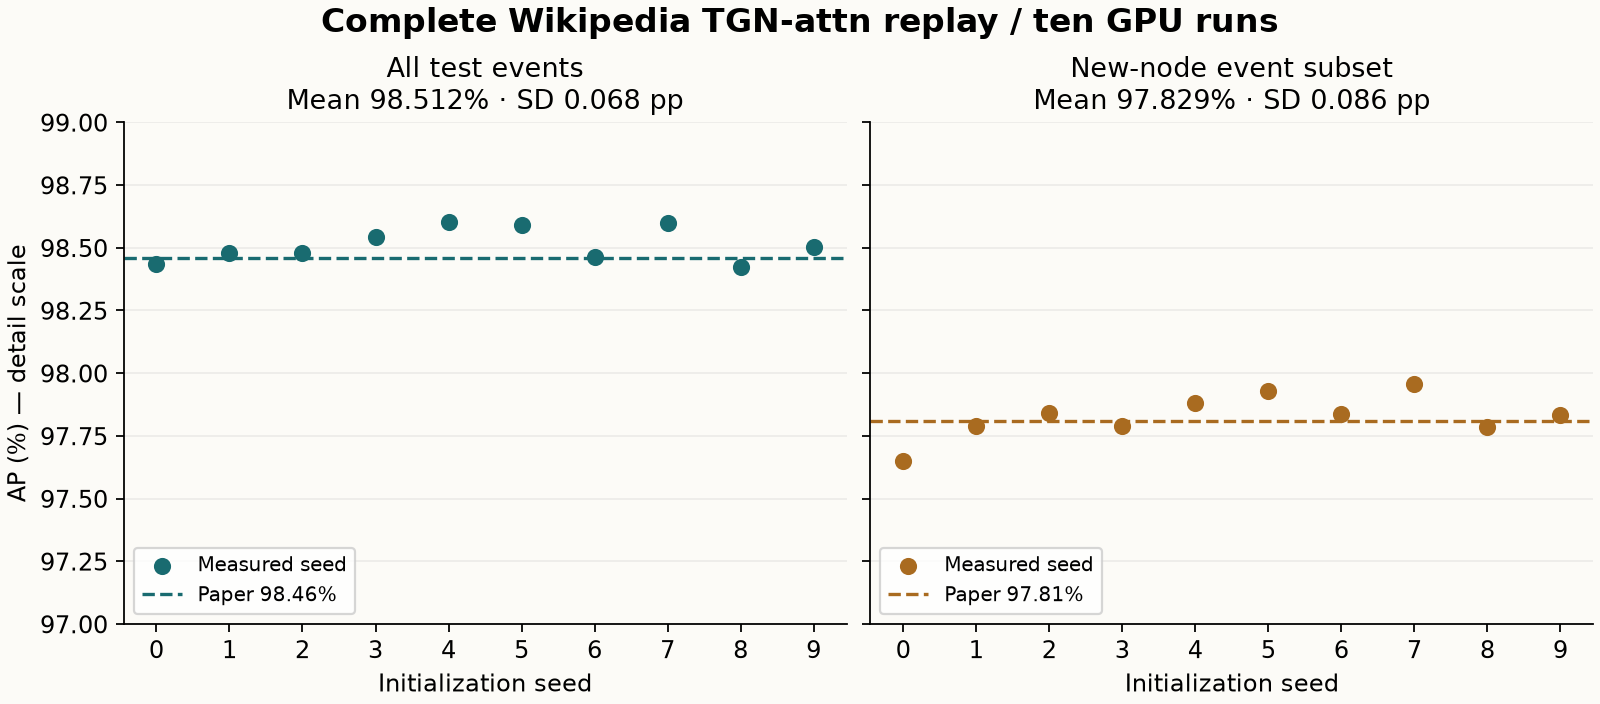<figcaption>Author-reference per-seed AP. Dashed lines are published targets; seeds share one fixed split.</figcaption></figure>

> **Scope check.** These are author-reference results, not proof of learner mastery. Numerical closeness cannot establish historical identity. Reddit, Twitter, dynamic node classification, competing models and the paper’s ablations are outside this selected replay. Full-paper reproduction remains **NOT_ESTABLISHED**.

**A separate short run.** The notebook’s default training exercise uses 600 real training events, 200 events per evaluation branch and two epochs, retaining the full feature widths and architecture. Neighbor retrieval still uses the complete strictly historical interaction index; optimization and memory replay are shortened. It is deliberately too small to claim the paper’s score. Its purpose is to prove that the learner’s three functions participate in a working train/evaluation loop.

| Seed | Short-run all-event AP | Short-run new-node AP |
|---|---:|---:|
| 0 | 82.1871% | 71.8465% |
| 1 | 68.4503% | 68.7762% |
| 2 | 76.2900% | 66.6147% |

**MEASURED teaching evidence; INCOMPARABLE to paper scores.** The subsets have different event populations from the complete target.

## 9 · Lab, checks and written defense

In the [student notebook](https://avistian.github.io/relational/labs/0102-temporal-graph-networks.ipynb), implement last-message selection, raw-message concatenation and the differentiable GRU state update. Run each CHECK before continuing. All data processing, attention, decoder, optimizer loop and evaluation are visible in the notebook. The full experiment is gated explicitly because it takes much longer than the teaching run.

**Verified mechanism boundaries.** The checker compares a repeated-node stream against the pinned original implementation, including probabilities, memory, pending messages and parameter gradients. Additional tests cover current-event feature leakage, strict neighbor cutoffs, padding, mutation safety and consistent state restoration. These are implementation tests, not paper-score evidence.

**EXIT — submit five answers with your run artifacts.**

1. Trace A’s pending message and committed memory across the first two batches. Explain why the time-2 query can see a time-1 edge but not its memory update.
2. Draw the gradient path that trains the GRU. State exactly where detaching breaks that path across batches.
3. Explain why hypothetical negatives never write memory, but real test events can change later test predictions.
4. Recompute one batch AP and the final unweighted batch mean from saved scores. Contrast it with pooled AP.
5. Separate completed runs, numerical tolerance, historical differences and the experiments still unrun. Explain the checkpoint caveat without calling it a harmless implementation detail.

Status stays **PENDING_WRITTEN_DEFENSE** until you supply that reasoning. Ask the teacher follow-up questions about any state transition or equation you cannot yet explain cold.

**Next connection.** L103 studies TGAT’s time-encoded attention without TGN’s node memory. L104 will audit leakage through the whole temporal pipeline. In relational modeling, carry both ideas forward: legal historical access from L101 and explicit state-transition boundaries from L102.

Keep the [TGN reference card](https://avistian.github.io/relational/reference/tgn-memory.html) for later retrieval. Revisit the memory/embedding distinction tomorrow, then explain the delayed-gradient trick again a week later without opening this lesson.


## Visible implementation

Source-informed one-layer TGN-attn port. The original Apache-2.0 release is pinned at `e38cdf85998c6ca077167610dc4e769a688efa95`. This focused implementation exposes all computations used below. Source parity checks are a separate artifact, not a substitute for result reproduction.

### PROVIDED · Imports and immutable experiment identities

In [ ]:
import copy
import hashlib
import json
import math
import random
import time
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.metrics import average_precision_score, roc_auc_score

SOURCE_COMMIT = 'e38cdf85998c6ca077167610dc4e769a688efa95'
DATA_URL = 'https://snap.stanford.edu/jodie/wikipedia.csv'
DATA_SHA256 = 'a6b73e09c0d1e5b9db11e7e7aa416f2e87838a745273e0446a79952cf4cfae09'
PAPER_AP = {'all': 98.46, 'new': 97.81}
CLOSE_TOLERANCE_PP = 0.5

### TODO · Task 1: last-message aggregation

In [ ]:
def last_message_indices(node_ids):
    """Last occurrence per node, returned in sorted-node order (chronological input)."""
    # TODO: implement the contract and retain the gradient path where required.
    raise NotImplementedError("last_message_indices")

### CHECK — do not edit

In [ ]:
assert last_message_indices(np.array([2,1,2,1])).tolist()==[3,2], 'Return the final occurrence in sorted node order'
assert last_message_indices(np.array([],dtype=int)).dtype==np.int64
assert last_message_indices(np.array([7,7,7])).tolist()==[2]
print('PASS: repeated IDs, single node, empty batch')

### TODO · Task 2: raw interaction messages

In [ ]:
def raw_messages(own, other, edge, elapsed, time_encoder):
    """Eq. 1 identity message: [own state, other state, event features, elapsed encoding]."""
    # TODO: implement the contract and retain the gradient path where required.
    raise NotImplementedError("raw_messages")

### CHECK — do not edit

In [ ]:
enc=lambda t: torch.stack([t,t+1],dim=-1)
own=torch.tensor([[1.,2.]]); other=torch.tensor([[3.,4.]])
msg=raw_messages(own,other,torch.tensor([[5.,6.]]),torch.tensor([7.]),enc)
assert msg.shape==(1,8), 'Two memories, edge and encoded time must all survive'
assert torch.equal(msg,torch.arange(1.,9.)[None]), 'Check endpoint order and elapsed encoding'
print('PASS: message order and shape')

### TODO · Task 3: differentiable memory update

In [ ]:
def update_state(memory, last_update, nodes, messages, timestamps, gru):
    """New candidate state; do not mutate the pre-event state that messages refer to."""
    # TODO: implement the contract and retain the gradient path where required.
    raise NotImplementedError("update_state")

### CHECK — do not edit

In [ ]:
torch.manual_seed(3)
gru=nn.GRUCell(3,2); old=torch.zeros(4,2); clock=torch.zeros(4)
msg=torch.tensor([[1.,2.,3.],[3.,1.,2.]])
new,times=update_state(old,clock,[1,3],msg,torch.tensor([2.,4.]),gru)
assert torch.equal(old,torch.zeros_like(old)) and torch.equal(clock,torch.zeros_like(clock)), 'Inputs were mutated'
assert torch.equal(new[[0,2]],old[[0,2]])
assert times.tolist()==[0.,2.,0.,4.]
assert torch.allclose(new[[1,3]],gru(msg,old[[1,3]]))
new.sum().backward();assert gru.weight_ih.grad.abs().sum()>0, 'Do not detach the candidate update'
print('PASS: values, clocks, untouched nodes, mutation safety, GRU gradient')
try:
    update_state(old,torch.tensor([0.,5.,0.,0.]),[1],msg[:1],torch.tensor([4.]),gru)
except (AssertionError,ValueError):
    pass
else:
    raise AssertionError('Reject an update older than the node clock')
empty,empty_clock=update_state(old,clock,[],None,None,gru)
assert torch.equal(empty,old) and torch.equal(empty_clock,clock)
print('PASS: backward-time rejection and empty message set')

### PROVIDED · Strict temporal adjacency and release negative sampling

In [ ]:
def temporal_neighbors(u, v, t, edge_ids, n_nodes):
    adjacency = [[] for _ in range(n_nodes)]
    for a, b, when, eid in zip(u, v, t, edge_ids):
        adjacency[int(a)].append((int(b), int(eid), float(when)))
        adjacency[int(b)].append((int(a), int(eid), float(when)))
    adjacency = [np.asarray(sorted(rows, key=lambda x: x[2]), dtype=np.float64).reshape(-1, 3)
                 for rows in adjacency]
    def find(nodes, cutoffs, count):
        neighbors = np.zeros((len(nodes), count), dtype=np.int64)
        ids = np.zeros_like(neighbors)
        times = np.zeros(neighbors.shape, dtype=np.float32)
        for row, (node, cutoff) in enumerate(zip(nodes, cutoffs)):
            history = adjacency[int(node)]
            end = np.searchsorted(history[:, 2], cutoff, side='left')
            chosen = history[max(0, end-count):end]
            if len(chosen):
                neighbors[row, -len(chosen):] = chosen[:, 0]
                ids[row, -len(chosen):] = chosen[:, 1]
                times[row, -len(chosen):] = chosen[:, 2]
        return neighbors, ids, times
    return find


class NegativeSampler:
    """Uniform destinations; consume the unused source draw to preserve release RNG order."""
    def __init__(self, events, seed=None):
        self.sources = np.unique(events['u'])
        self.destinations = np.unique(events['v'])
        self.seed = seed
        self.reset()
    def reset(self):
        self.rng = np.random if self.seed is None else np.random.RandomState(self.seed)
    def sample(self, size):
        self.rng.randint(0, len(self.sources), size)
        return self.destinations[self.rng.randint(0, len(self.destinations), size)]

### PROVIDED · Time encoder and merge blocks

In [ ]:
class TimeEncoder(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.w = nn.Linear(1, dim)
        self.w.weight = nn.Parameter(torch.tensor(1 / 10 ** np.linspace(0, 9, dim), dtype=torch.float32)[:, None])
        self.w.bias = nn.Parameter(torch.zeros(dim))
    def forward(self, elapsed):
        return torch.cos(self.w(elapsed.unsqueeze(-1)))


class Merge(nn.Module):
    def __init__(self, left, right, hidden, out):
        super().__init__()
        self.fc1, self.fc2 = nn.Linear(left+right, hidden), nn.Linear(hidden, out)
        nn.init.xavier_normal_(self.fc1.weight)
        nn.init.xavier_normal_(self.fc2.weight)
    def forward(self, left, right):
        return self.fc2(torch.relu(self.fc1(torch.cat([left, right], dim=-1))))

### PROVIDED · Complete one-layer TGN-attn encoder and decoder

In [ ]:
class TGN(nn.Module):
    def __init__(self, node_features, edge_features, dropout=0.1, neighbors=10):
        super().__init__()
        d = node_features.shape[1]
        self.dim, self.neighbors = d, neighbors
        self.register_buffer('node_features', torch.as_tensor(node_features, dtype=torch.float32))
        self.register_buffer('edge_features', torch.as_tensor(edge_features, dtype=torch.float32))
        self.time_encoder = TimeEncoder(d)
        self.gru = nn.GRUCell(3*d+edge_features.shape[1], d)
        self.merge = Merge(2*d, d, d, d)
        self.attention = nn.MultiheadAttention(2*d, 2, kdim=2*d+edge_features.shape[1],
                                              vdim=2*d+edge_features.shape[1], dropout=dropout)
        self.decoder = Merge(d, d, d, 1)
        self.register_buffer('memory', torch.zeros_like(self.node_features))
        self.register_buffer('last_update', torch.zeros(len(node_features)))
        self.pending = {}
        self.finder = None
    def reset_state(self):
        self.memory.zero_(); self.last_update.zero_(); self.pending = {}
    def detach_state(self):
        self.memory = self.memory.detach()
        self.pending = {k: (m.detach(), t.detach()) for k, (m, t) in self.pending.items()}
    def snapshot(self):
        return (self.memory.detach().clone(), self.last_update.clone(),
                {k: (m.detach().clone(), t.clone()) for k, (m, t) in self.pending.items()})
    def restore(self, state):
        self.memory, self.last_update, self.pending = copy.deepcopy(state)
    def candidate_state(self):
        nodes = sorted(self.pending)
        messages = torch.stack([self.pending[k][0] for k in nodes]) if nodes else None
        times = torch.stack([self.pending[k][1] for k in nodes]) if nodes else None
        return update_state(self.memory, self.last_update, nodes, messages, times, self.gru)
    def embed(self, nodes, timestamps, state):
        device = self.memory.device
        node_ids = torch.as_tensor(nodes, dtype=torch.long, device=device)
        own = state[node_ids] + self.node_features[node_ids]
        neighbors, edges, times = self.finder(nodes, timestamps, self.neighbors)
        neighbors = torch.as_tensor(neighbors, dtype=torch.long, device=device)
        edges = torch.as_tensor(edges, dtype=torch.long, device=device)
        elapsed = torch.as_tensor(timestamps[:, None] - times, dtype=torch.float32, device=device)
        query = torch.cat([own[:, None], self.time_encoder(torch.zeros((len(nodes), 1), device=device))], dim=-1)
        key = torch.cat([state[neighbors]+self.node_features[neighbors], self.edge_features[edges],
                         self.time_encoder(elapsed)], dim=-1)
        mask = neighbors == 0
        empty = mask.all(dim=1)
        mask[empty, 0] = False  # MHA softmax must not receive an all-masked row.
        output, _ = self.attention(query.transpose(0, 1), key.transpose(0, 1), key.transpose(0, 1),
                                   key_padding_mask=mask)
        output = output.squeeze(0).masked_fill(empty[:, None], 0)
        return self.merge(output, own)
    def probabilities(self, u, v, negative, timestamps, edge_ids):
        """Score first using old messages; queue current positive events only afterward."""
        state, clock = self.candidate_state()
        embeddings = self.embed(np.concatenate([u, v, negative]), np.tile(timestamps, 3), state)
        src, dst, neg = embeddings.chunk(3)
        # Persist consumed messages only for real endpoints, exactly as release TGN does.
        positives = np.unique(np.concatenate([u, v]))
        with torch.no_grad():
            self.memory[positives] = state[positives]
            self.last_update[positives] = clock[positives]
        for node in positives:
            self.pending.pop(int(node), None)
        device = self.memory.device
        when = torch.as_tensor(timestamps, dtype=torch.float32, device=device)
        # Source and destination messages both use the same pre-current-event state.
        for own, other in [(u, v), (v, u)]:
            messages = raw_messages(self.memory[own], self.memory[other], self.edge_features[edge_ids],
                                    when-self.last_update[own], self.time_encoder)
            for idx in last_message_indices(own):
                self.pending[int(own[idx])] = (messages[idx], when[idx])
        scores = self.decoder(torch.cat([src, src]), torch.cat([dst, neg])).flatten().sigmoid()
        return scores.chunk(2)

### PROVIDED · Complete data preprocessing and frozen release split

In [ ]:
def load_wikipedia(directory):
    directory = Path(directory); directory.mkdir(parents=True, exist_ok=True)
    path = directory/'wikipedia.csv'
    if not path.exists():
        urllib.request.urlretrieve(DATA_URL, path)
    sha = hashlib.file_digest(path.open('rb'), 'sha256').hexdigest()
    assert sha == DATA_SHA256, f'Dataset checksum mismatch: {sha}'
    cache = directory/'processed.npz'
    if cache.exists():
        z = np.load(cache)
        # The raw identity alone cannot authenticate an arbitrary processed cache.
        if str(z['raw_sha']) != sha:
            raise ValueError('Processed cache belongs to other raw bytes')
        u,v,t,x = (z[k] for k in ['u','v','t','x'])
    else:
        # Header has four columns, rows additionally have 172 edge features.
        a = np.loadtxt(path, delimiter=',', skiprows=1)
        u = a[:, 0].astype(np.int64)+1
        v = a[:, 1].astype(np.int64)+int(u.max())+1
        t,x = a[:, 2], a[:, 4:].astype(np.float32)
        np.savez(cache, u=u,v=v,t=t,x=x,raw_sha=sha)
    assert len(u)==157474 and x.shape==(157474,172)
    assert np.all(np.diff(t)>=0) and len(set(u)|set(v))==9227
    edges = np.vstack([np.zeros((1,172),np.float32),x])
    nodes = np.zeros((int(max(u.max(),v.max()))+1,172),np.float32)
    full = {'u':u,'v':v,'t':t,'e':np.arange(1,len(u)+1)}
    val_time,test_time = np.quantile(t,[.70,.85])
    candidates = set(u[t>val_time]) | set(v[t>val_time])
    # Python 3.9 random.sample(set, k) internally converted to tuple. Preserve that order.
    held = set(random.Random(2020).sample(tuple(candidates),int(.1*(len(nodes)-1))))
    train_mask = (t<=val_time)&~np.isin(u,list(held))&~np.isin(v,list(held))
    seen = set(u[train_mask])|set(v[train_mask]); unseen=(set(u)|set(v))-seen
    novel = np.isin(u,list(unseen))|np.isin(v,list(unseen))
    masks={'train':train_mask,'val':(t>val_time)&(t<=test_time),'test':t>test_time}
    masks['new_val']=masks['val']&novel; masks['new_test']=masks['test']&novel
    data={name:{k:a[mask] for k,a in full.items()} for name,mask in masks.items()}
    data['full']=full
    audit={'raw_sha256':sha,'cutoffs':[float(val_time),float(test_time)],
           'counts':{k:len(d['u']) for k,d in data.items()},'held_nodes':sorted(int(i) for i in held),
           'split_sha256':{k:hashlib.sha256(d['e'].tobytes()).hexdigest() for k,d in data.items()}}
    return nodes,edges,data,audit

### PROVIDED · Full chronological train/evaluation loops and named-target runner

In [ ]:
def batches(events, size=200):
    for start in range(0,len(events['u']),size):
        yield {k:v[start:start+size] for k,v in events.items()}


def evaluate(model, events, sampler, batch_size=200):
    model.eval(); sampler.reset(); aps=[]; aucs=[]; saved=[]
    with torch.no_grad():
        for b in batches(events,batch_size):
            neg=sampler.sample(len(b['u']))
            positive,negative=model.probabilities(b['u'],b['v'],neg,b['t'],b['e'])
            p=np.concatenate([positive.cpu().numpy(),negative.cpu().numpy()])
            y=np.concatenate([np.ones(len(positive)),np.zeros(len(negative))])
            aps.append(float(average_precision_score(y,p))); aucs.append(float(roc_auc_score(y,p)))
            saved.append({'edges':b['e'],'negative':neg,'positive':positive.cpu().numpy(),'negative_score':negative.cpu().numpy()})
    return {'ap':float(np.mean(aps)),'auc':float(np.mean(aucs)),'batch_ap':aps,'batch_auc':aucs},saved


def run_training(nodes,edges,data,seed=0,epochs=50,patience=5,batch_size=200,output=None,device='cpu'):
    """Fixed-seed modern port. Release checkpoint/pending-message behavior is preserved."""
    torch.manual_seed(seed); np.random.seed(seed)
    model=TGN(nodes,edges).to(device)
    full_finder=temporal_neighbors(**{'u':data['full']['u'],'v':data['full']['v'],'t':data['full']['t'],
                                    'edge_ids':data['full']['e'],'n_nodes':len(nodes)})
    train=data['train']
    train_finder=temporal_neighbors(train['u'],train['v'],train['t'],train['e'],len(nodes))
    train_sampler=NegativeSampler(train)
    val_sampler=NegativeSampler(data['full'],0)
    test_sampler=NegativeSampler(data['full'],2)
    new_sampler=NegativeSampler(data['new_test'],3)
    optimizer=torch.optim.Adam(model.parameters(),lr=1e-4)
    trace=[]; best=-float('inf'); rounds=0; best_epoch=0; best_weights=None; stop=False
    for epoch in range(epochs):
        start=time.perf_counter();model.reset_state();model.finder=train_finder;model.train();losses=[]
        for b in batches(train,batch_size):
            optimizer.zero_grad()
            p,n=model.probabilities(b['u'],b['v'],train_sampler.sample(len(b['u'])),b['t'],b['e'])
            loss=nn.functional.binary_cross_entropy(p,torch.ones_like(p))+nn.functional.binary_cross_entropy(n,torch.zeros_like(n))
            loss.backward();optimizer.step();model.detach_state();losses.append(float(loss.detach()))
        model.finder=full_finder
        train_state=model.snapshot()
        val,_=evaluate(model,data['val'],val_sampler,batch_size)
        val_state=model.snapshot();model.restore(train_state)
        # The released trainer intentionally passes the full-node validation sampler here.
        new_val,_=evaluate(model,data['new_val'],val_sampler,batch_size)
        model.restore(val_state)
        improved=best_weights is None or (val['ap']-best)/abs(best)>1e-10
        if improved:
            best=val['ap'];best_epoch=epoch;rounds=0
            best_weights={k:v.detach().clone() for k,v in model.state_dict().items()
                          if k not in ['node_features','edge_features']}
        else: rounds+=1
        row={'epoch':epoch,'loss':float(np.mean(losses)),'val_ap':val['ap'],'new_val_ap':new_val['ap'],
             'seconds':time.perf_counter()-start}
        trace.append(row);print(json.dumps({'seed':seed,**row}),flush=True)
        if output:
            Path(output).mkdir(parents=True,exist_ok=True)
            (Path(output)/f'seed-{seed}-progress.json').write_text(json.dumps(trace,indent=2))
        if rounds>=patience:
            # Release does not serialize pending messages in state_dict. Keep stopping-epoch
            # pending messages when restoring its best weights and persistent memory.
            model.load_state_dict(best_weights,strict=False);stop=True;break
    # Release uses the final epoch if the maximum is reached without early stopping.
    selected=best_epoch if stop else len(trace)-1
    val_state=model.snapshot()
    test,predictions=evaluate(model,data['test'],test_sampler,batch_size)
    model.restore(val_state)
    new_test,new_predictions=evaluate(model,data['new_test'],new_sampler,batch_size)
    model.restore(val_state)
    result={'seed':seed,'epochs_completed':len(trace),'selected_epoch':selected,'early_stopped':stop,
            'test':test,'new_test':new_test,'trace':trace,
            'seed_protocol':'Independent explicit seed per run; release originally seeds once before ten runs',
            'checkpoint_policy':'release: best state_dict on early stop; pending messages from stopping epoch'}
    if output:
        out=Path(output)
        torch.save({'weights':{k:v for k,v in model.state_dict().items() if k not in ['node_features','edge_features']},
                    'temporal_state':model.snapshot(),'result':result},out/f'seed-{seed}.pt')
        arrays={f'{lane}_{k}':np.concatenate([b[k] for b in values])
                for lane,values in [('all',predictions),('new',new_predictions)] for k in values[0]}
        np.savez_compressed(out/f'seed-{seed}-predictions.npz',**arrays)
        (out/f'seed-{seed}.json').write_text(json.dumps(result,indent=2))
    return result

## Real data and the live training loop

Predict whether two epochs on 600 events can justify the complete-paper target. The answer does not depend on whether the score looks impressive.

In [ ]:
torch.set_num_threads(1)
node_features,edge_features,data,split_audit=load_wikipedia(Path('l102-cache'))
display(pd.DataFrame([split_audit['counts']]))
small={k:{f:x[:(600 if k=='train' else 200)] for f,x in d.items()} if k!='full' else d for k,d in data.items()}
fresh=run_training(node_features,edge_features,small,seed=0,epochs=2,output=Path('l102-teaching'))
display(pd.DataFrame([{'population':name,'AP':fresh[key]['ap'],'ROC_AUC':fresh[key]['auc']} for name,key in [('all events','test'),('new-node subset','new_test')]]))
print('MEASURED teaching run; paper comparison INCOMPARABLE')

## EXIT TICKET

Submit your three functions, `l102-teaching/seed-0.json` and the five-part written defense in section 9. Identify exactly which state is restored by the release checkpoint and which state remains from the stopping epoch. Running this prepared solution does not establish mastery. **PENDING_WRITTEN_DEFENSE**.

## Complete selected paper experiment — explicit long-run gate

Ten independent seeds, complete Wikipedia splits, up to 50 epochs and patience five. No training subset. CPU can take hours; a GPU runtime is recommended. This executes the visible implementation above, including your functions. Use a new output directory after any code change. Compare both means against the frozen 0.5 percentage-point tolerance, then separately report the historical-identity gap. All other paper experiments remain NOT_RUN.

In [ ]:
RUN_PAPER_REPRO = False
if RUN_PAPER_REPRO:
    device='cuda' if torch.cuda.is_available() else 'cpu'
    paper_records=[run_training(node_features,edge_features,data,seed=s,epochs=50,output=Path('l102-paper'),device=device) for s in range(10)]
    rows=[]
    for lane,key in [('all','test'),('new','new_test')]:
        a=np.array([r[key]['ap']*100 for r in paper_records])
        rows.append({'population':lane,'mean_AP_percent':a.mean(),'sample_SD_pp':a.std(ddof=1),'paper_AP':PAPER_AP[lane],'numerical_verdict':'CLOSE' if abs(a.mean()-PAPER_AP[lane])<=CLOSE_TOLERANCE_PP else 'OUTSIDE_TOLERANCE'})
    display(pd.DataFrame(rows))
    print('Selected experiment COMPLETE; historical identity INCOMPARABLE; full paper NOT_ESTABLISHED')
else:
    print('Full selected replay NOT_RUN in this kernel. See separately labeled author-reference evidence.')